In [1]:
import os
os.chdir('./../')

In [9]:
from src.visualization.dempster_shafer_uncertainity_plot import DempsterShaferUncertaintyPlot
from notebooks.sngp_gpt import SNGPResNet
from src.data.utils import HFDataset
from datasets import load_dataset
from torch.utils.data import DataLoader

In [5]:
import numpy as np
import random
import torch
from torchvision import transforms

In [4]:
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
normalize_mean = [0.485, 0.456, 0.406]
normalize_std = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224), # Randomly crop and resize to 224x224
    transforms.RandomHorizontalFlip(), # Randomly flip the image horizontally
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_mean, std=normalize_std)
])

transform_test = transforms.Compose([
    transforms.RandomResizedCrop(224), # Randomly crop and resize to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_mean, std=normalize_std)
])

In [7]:
model = SNGPResNet(
    num_classes=8,         # <-- change to your dataset
    arch="resnet18",
    pretrained=False,         # ok to start from ImageNet
    rff_dim=1024,            # 256–1024 is a good range
    length_scale=1.0,
    ridge_penalty=1e-3,
    cov_momentum=0.999,
    mean_field=True,
).cuda()

model.load_state_dict(torch.load("notebooks/sngp_resnet18_checkpoint.pth"))

model.eval()

SNGPResNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

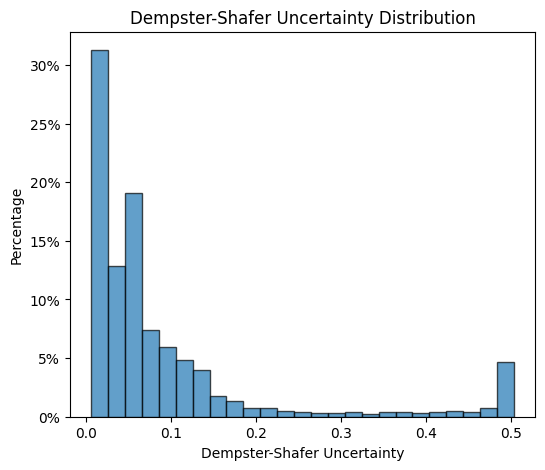

In [10]:
data = load_dataset("nirschl-lab/acevedo_et_al_2020")
ood_data_ = data['test'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_test, fold='test')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
# quick eval
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())


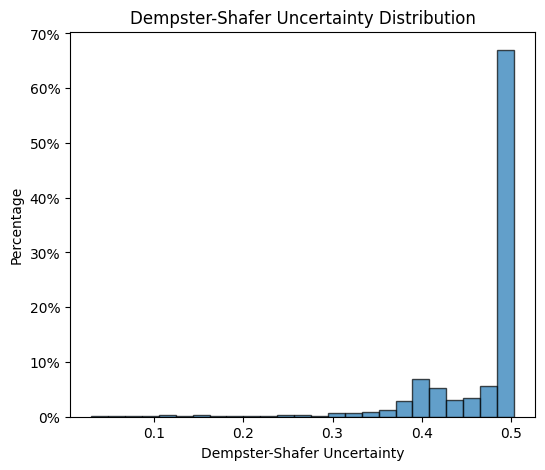

In [11]:
data = load_dataset("nirschl-lab/kather_et_al_2016")
ood_data_ = data['train'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_test, fold='train')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
# quick eval
model.eval()
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())

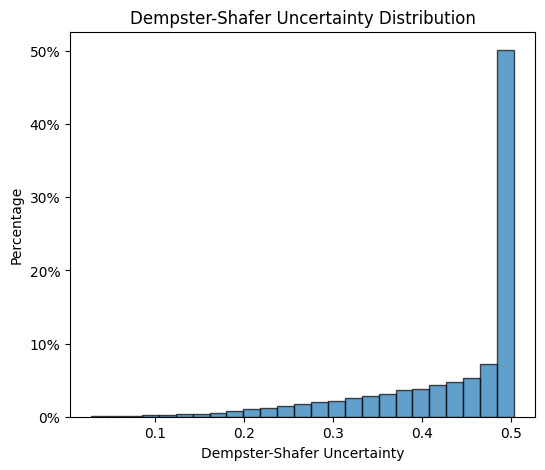

In [12]:
data = load_dataset("nirschl-lab/kather_et_al_2018")
ood_data_ = data['train'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_test, fold='train')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
# quick eval
model.eval()
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())


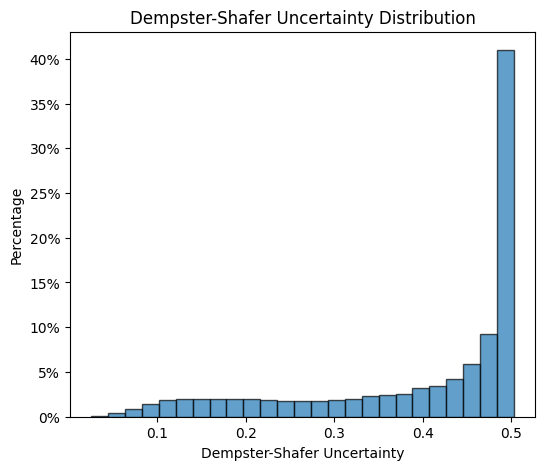

In [13]:
data = load_dataset("nirschl-lab/tang_et_al_2019")
ood_data_ = data['train'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_test, fold='train')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
# quick eval
model.eval()
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())


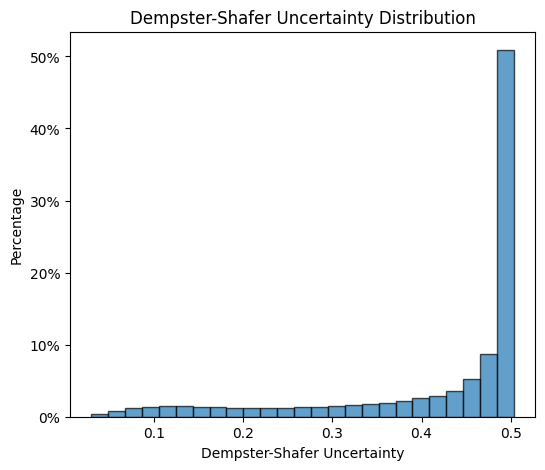

In [14]:
data = load_dataset("nirschl-lab/wong_et_al_2022")
ood_data_ = data['train'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_test, fold='train')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
# quick eval
model.eval()
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())


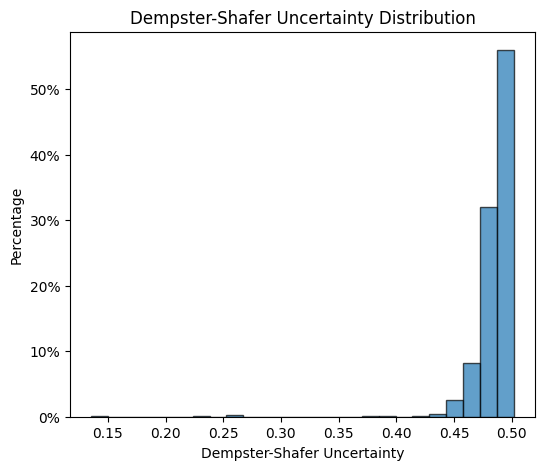

In [15]:
data = load_dataset("nirschl-lab/nirschl_et_al_2018")
ood_data_ = data['train'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_test, fold='train')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
# quick eval
model.eval()
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())
